# **Introduction**

I am going to use the Nvidia historical stock data for my time series analysis. I will organise my work in numbered steps. I will introduce what I am going to do before every code cell and then add any description required after the code execution.

# **Table of Contents**

1. Organising all the pip installs and library imports
2. Retrieving and plotting 5 year daily historical Nvidia stock data
3. Retrieving and plotting 2023 onward daily historical Nvidia stock data
4. Seasonality Test
5. Stationarity Test
6. Differencing
7. Implementing ARIMA (p, d, q) Model
8. Prophet Model
9. Monte Carlo simulation for future price paths
10. Monte Carlo simulation for European option valuation
11. Real life option valuation

# **1. Organising all the pip installs and library imports**

In [6]:
# Pip installs
!pip install yfinance --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install statsmodels --quiet
!pip install numpy --quiet
!pip install prophet --quiet
!pip install scikit-learn --quiet

In [7]:
# Importing libraries
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# **2. Retrieving and plotting 5 year daily historical Nvidia stock data**

[*********************100%***********************]  1 of 1 completed


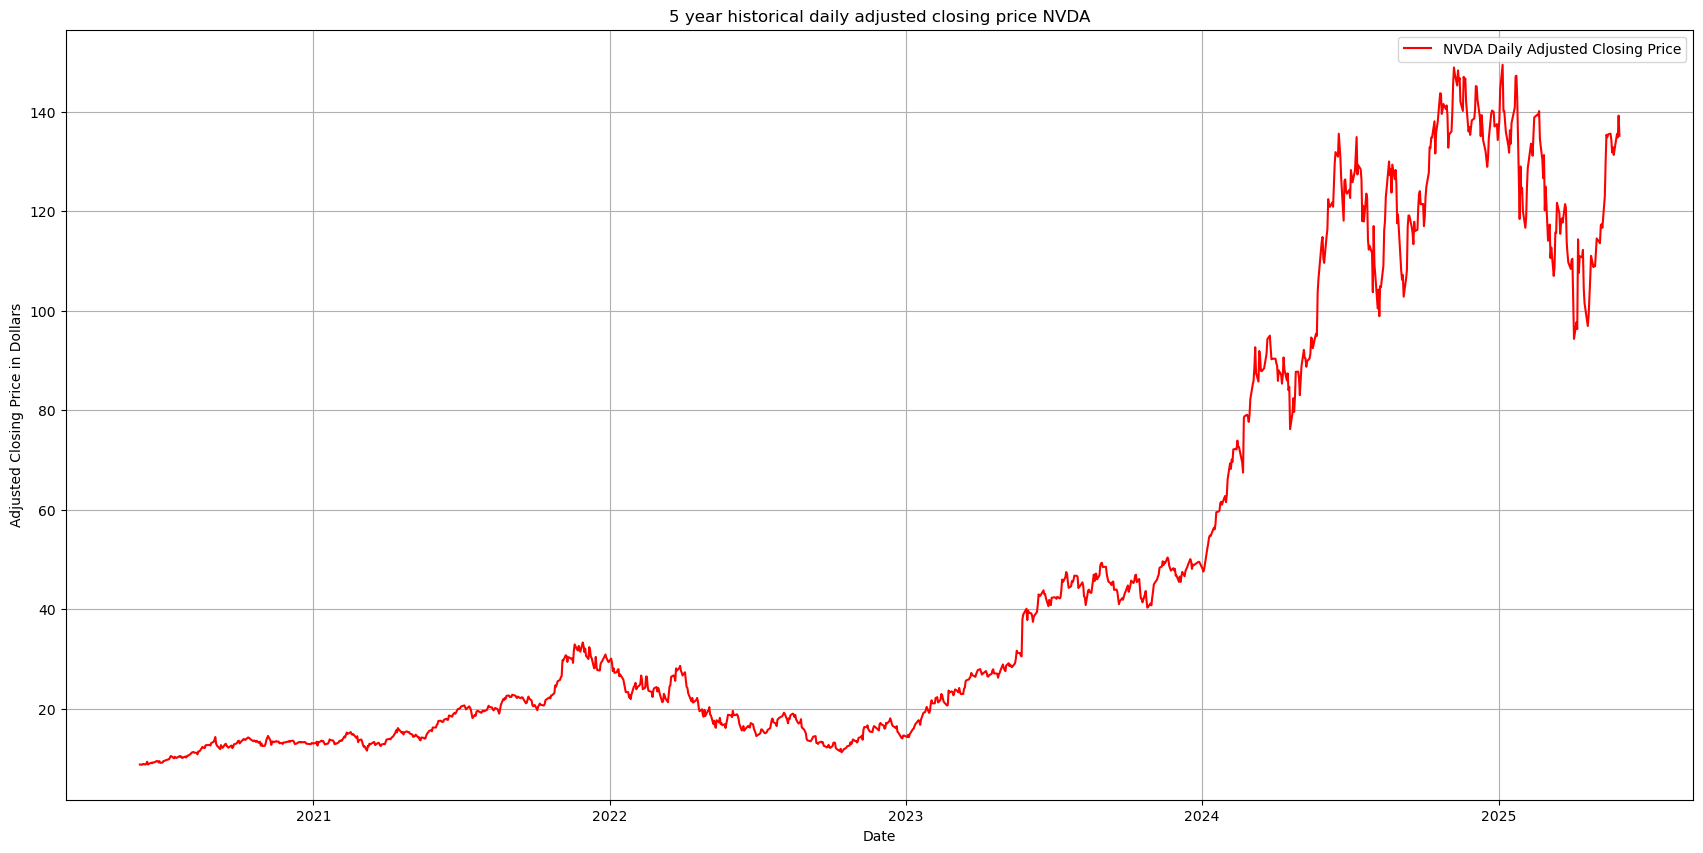

In [ ]:
# Importing the Nvidia data using yfinance
nvidia = pd.DataFrame(yf.download("NVDA", start = "2020-06-01", end = "2025-06-01", auto_adjust = False)[["Adj Close"]]).dropna()

# PLotting the Nvidia data
plt.figure(figsize = (21, 10))
plt.grid(True)
plt.ylabel("Adjusted Closing Price in Dollars")
plt.xlabel("Date")
plt.title("5 year historical daily adjusted closing price NVDA")
plt.plot(nvidia["Adj Close"], label = "NVDA Daily Adjusted Closing Price", color="red")
plt.legend()
plt.show()

**Description:** The data before 2023 is totally different and quite stable and low as well. This will act as an outlier. It will reduce the accuracy of my model. I am going to use data onwards from 2023.

# **3. Retrieving and plotting 2023 onward daily historical Nvidia stock data**

[*********************100%***********************]  1 of 1 completed


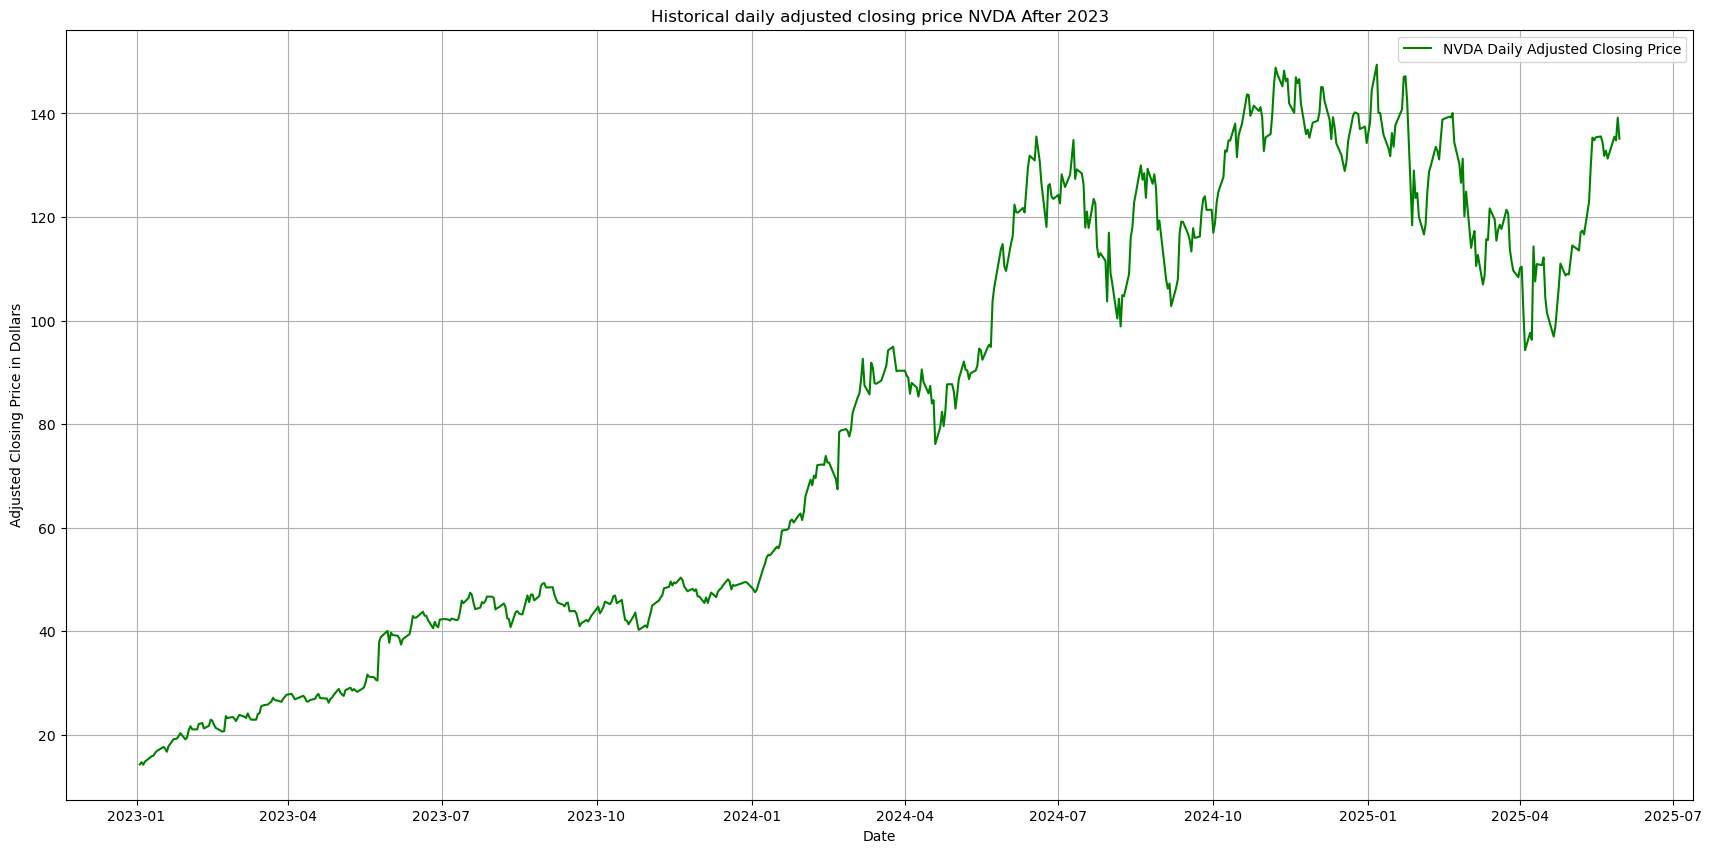

In [ ]:
# Importing and plotting weekly historical Nvidia data from 2023 onwards
nvidia_new = pd.DataFrame(yf.download("NVDA", start="2023-01-01", end="2025-06-01", auto_adjust=False)[["Adj Close"]]).dropna()

# PLotting the Nvidia data
plt.figure(figsize=(21, 10))
plt.grid(True)
plt.ylabel("Adjusted Closing Price in Dollars")
plt.xlabel("Date")
plt.title("Historical daily adjusted closing price NVDA After 2023")
plt.plot(nvidia_new["Adj Close"].dropna(), label="NVDA Daily Adjusted Closing Price", color="green")
plt.legend()
plt.show()

**Description:** This data looks much better and it does not contain any obvious outliers. I will be using this data for my analysis.

# **4. Seasonality Test**

I am going to check if my data has seasonality or not.

## (a) Visual

Analysing why there is no seasonality based on the visuals of the plotted data above.

- As we can see from the plot above, the data shows a clear upward trend but there is no sign of regular repetitions due to seasonality.

- Seasonality occurs when there are clear patterns that closely repeat at several intervals. There is no sign of consistent repition here.

## (b) ACF Plot

Plotting Auto Correlated Function (ACF) to check for seasonality.

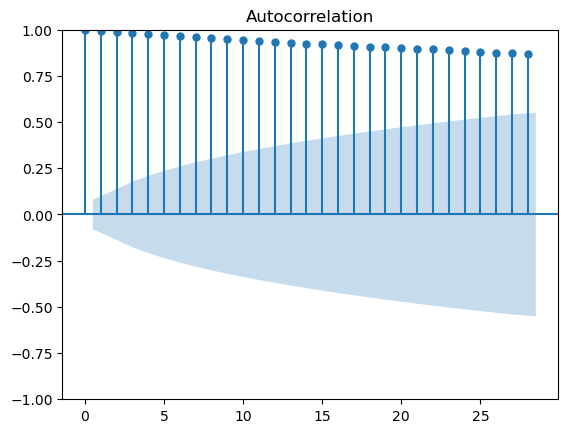

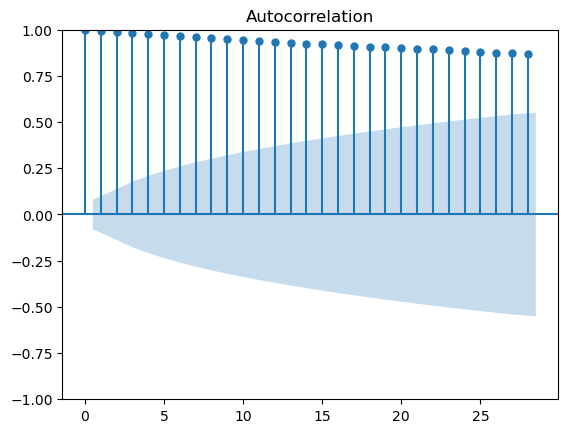

In [26]:
plot_acf(nvidia_new["Adj Close"]) # CHANGE: Argument to print my Nvidia data

**Description:**
- If there was a seasonal cycle we would observe consistent peaks at progressive intervals. That is not the case here.
- There are no up and down movements and also the ACF almost reduces to zero towars interval 1.
- So there is no siginificant seasonality present.

# **5. Stationarity Test**

## Testing for stationarity usind AD-Fuller test.

In [ ]:
# Defining ADF Test Function
def adf_test(nvidia_AdjClose):
   print("Augmented Dickey-Fuller Test: NVDA")
   result = adfuller(nvidia_AdjClose)
   labels = ["Test Statistic", "p-value", "Number of lags Used", "Number of Observations Used"]
   for value, label in zip(result, labels):
       print(f"{label}: {value}")
   if result[1] <= 0.05:
       print("The series is stationary because p-value <= 0.05.")
   else:
       print("The series is non-stationary because p-value >= 0.05..")

# Running ADF Test
adf_test(nvidia_new["Adj Close"])

Augmented Dickey-Fuller Test: NVDA
Test Statistic: -1.082139344278386
p-value: 0.7221417212484703
Number of lags Used: 3
Number of Observations Used: 600
The series is non-stationary because p-value >= 0.05..


**Description:** Since p-value > 0.05, I know that the data is not stationary, I am going to make it stationary using differencing.

# **6. Differencing**

We find the 1st order difference by calculating the consecutive difference between observed values in a time series.
\begin{equation}
\Delta y_t = y_t - y_{t-1}
\end{equation}

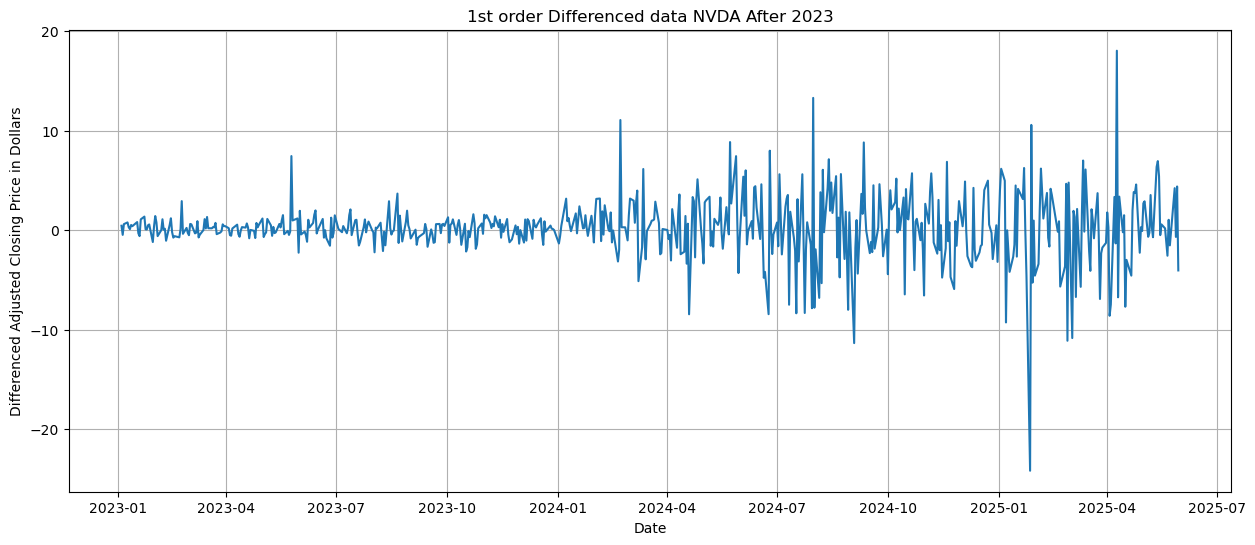

In [ ]:
# Differencing
nvidia_new["Diff Adj Close"] = nvidia_new["Adj Close"].diff()
nvidia_new.dropna(inplace = True)

# Plotting the differenced data
plt.figure(figsize=(15, 6))
plt.grid(True)
plt.ylabel("Differenced Adjusted Closing Price in Dollars")
plt.xlabel("Date")
plt.title("1st order Differenced data NVDA After 2023")
plt.plot(nvidia_new["Diff Adj Close"])
plt.show()

Now I will run AD-Fuller test again to confirm stationarity.

In [41]:
# Running ADF Test
adf_test(nvidia_new["Diff Adj Close"])

Augmented Dickey-Fuller Test: NVDA
Test Statistic: -14.894889816663955
p-value: 1.5376197103728704e-27
Number of lags Used: 2
Number of Observations Used: 600
The series is stationary because p-value <= 0.05.


**Description:** Since p-value < 0.05, I know that the data is now stationary after 1st order differecing. I can conclude that d = 1. We also know that there is no trend or seasonality, I am going to use ARIMA model by finding p and q first.

# **7. Implementing ARIMA (p, d, q) Model**

ARIMA model has three different components: AR, I and MA. Lets look at each to see what they represent.

**AR:** AR stands for autoregression and we use this to forecast future values based on the linear combination of previous values. This gives us the p
\begin{equation}
Y_t = C + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \epsilon_t
\end{equation}

**I:** This integrated part is simply the order of differencing required to make the data stationary. This gives us the d.
\begin{equation}
\Delta y_t = y_t - y_{t-1}
\end{equation}

**MA:** MA stands for moving average and in this we forecast future values using the past forecast errors instead of using observed values. This gives us the q.
\begin{equation}
Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}
\end{equation}

## (a) Plotting ACF and PACF to find p and q

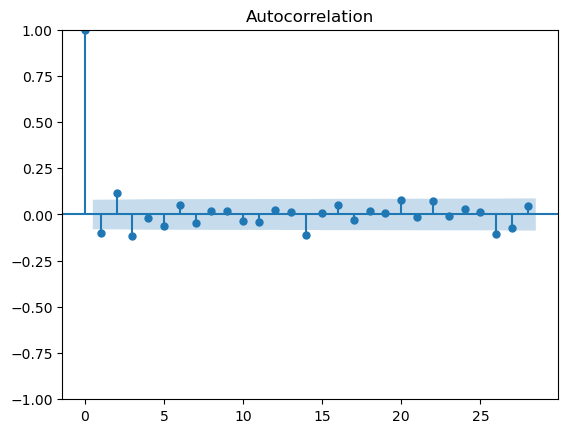

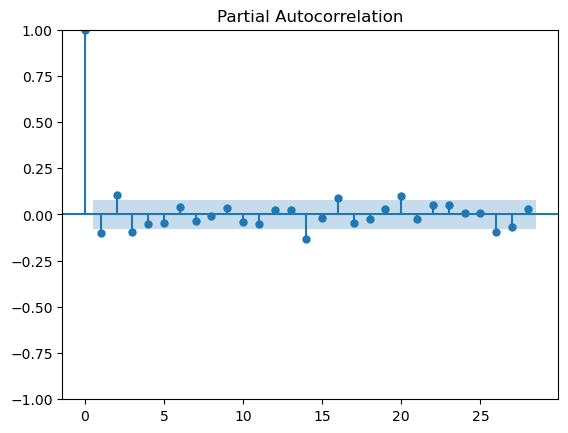

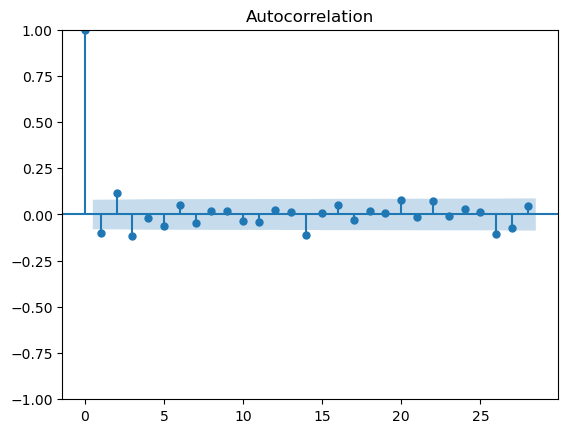

In [ ]:
# Plotting ACF and PACF
plot_pacf(nvidia_new["Diff Adj Close"])
plot_acf(nvidia_new["Diff Adj Close"])

**Description:** The PACF shows a sharp cutoff after lag 0, with the spike at lag 0 being significant and the rest within the confidence interval. so Lets try p = 0. The ACF also shows a sharp drop after lag 0, and the remaining lags are almost within the confidence bounds. so lets try q = 0.

# (b) Checking ARIMA Summary for different p and q

In [ ]:
# Trying ARIMA (0,1,0)
model = ARIMA(nvidia_new["Adj Close"], order=(0,1,0)) 
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                  603
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1548.857
Date:                Fri, 04 Jul 2025   AIC                           3099.714
Time:                        18:04:22   BIC                           3104.114
Sample:                             0   HQIC                          3101.426
                                - 603                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        10.0525      0.252     39.825      0.000       9.558      10.547
Ljung-Box (L1) (Q):                   6.08   Jarque-Bera (JB):              1961.33
Prob(Q):                              0.01   Pr

C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Trying ARIMA (1,1,1)
model = ARIMA(nvidia_new["Adj Close"], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                  603
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1541.244
Date:                Fri, 04 Jul 2025   AIC                           3088.489
Time:                        18:04:22   BIC                           3101.690
Sample:                             0   HQIC                          3093.627
                                - 603                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7877      0.080     -9.843      0.000      -0.945      -0.631
ma.L1          0.6886      0.092      7.496      0.000       0.509       0.869
sigma2         9.8010      0.252     38.842      0.0

In [ ]:
# Trying ARIMA (2,1,2)
model = ARIMA(nvidia_new["Adj Close"], order=(2,1,2))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                  603
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1540.621
Date:                Fri, 04 Jul 2025   AIC                           3091.243
Time:                        18:04:22   BIC                           3113.244
Sample:                             0   HQIC                          3099.806
                                - 603                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6421      0.827     -0.777      0.437      -2.262       0.978
ar.L2          0.0189      0.668      0.028      0.977      -1.290       1.328
ma.L1          0.5664      0.826      0.685      0.4

**Description:** ARIMA (2, 1, 2) gives p-values > 0.05, so it is not valid. ARIMA (1, 1, 1) gives the lowest AIC and BIC value, even lower than ARIMA (0, 1, 0). So I will use p = 1 and q = 1. I have explained AIC and BIC in more detail in my seminar thesis.

# (c) Implementing ARIMA (1, 1, 1).

C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\osama\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

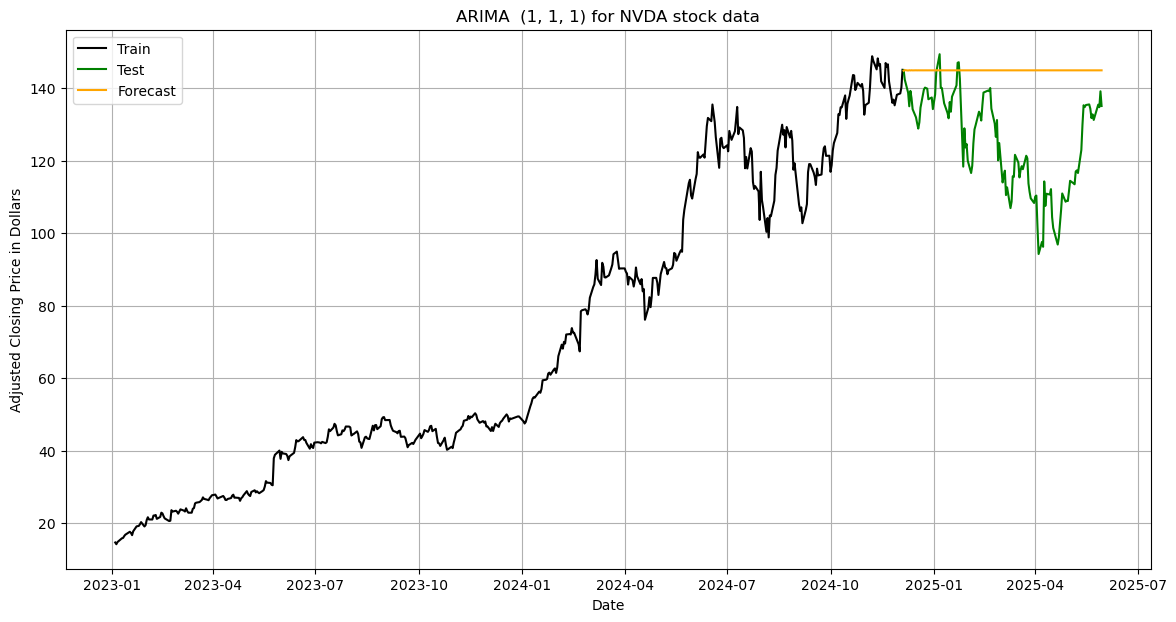

RMSE: 24.3263


In [ ]:
# Split data into train and test
train = nvidia_new.iloc[:-int(len(nvidia_new) * 0.2)]
test = nvidia_new.iloc[-int(len(nvidia_new) * 0.2):]

# Fit ARIMA model
model = ARIMA(train["Adj Close"], order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot the results
plt.figure(figsize=(14,7))
plt.grid(True)
plt.title("ARIMA  (1, 1, 1) for NVDA stock data")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price in Dollars")
plt.plot(train.index, train["Adj Close"], label="Train", color="black")
plt.plot(test.index, test["Adj Close"], label="Test", color="Green")
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.legend()
plt.show()

# Calculate RMSE
forecast = forecast[:len(test)]
test_close = test["Adj Close"][:len(forecast)]
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")

**Description:** I divided the data into train and test models. 80% of my data was used for training and 20% for testing. I plotted each line with different colors to make the difference clear. I calculated Root Mean Square Error (RMSE) which basically calculates the difference bwtween actual vs predicted values.
\begin{equation}
RMSE = \sqrt{\frac{\sum_{i=1}^{N} \left( \text{Predicted}_{i} - \text{Actual}_{i} \right)^{2}}{N}}
\end{equation}

The lower the value of RMSE, the better is our result. Th value here of 24.3263 is quite high. We can also see that our result is a flat line: Lets look at all the possible reasons for this and try to fix it.

**Possible problems:**
- One problem that I can see is that this error is occurring because I did not set the frequency for my data. I get a warning for that as well which says that my forecast could come out to be wrong.
- Another possible issue could be that the model is not right for my data.
- Limited amount of data could be another reason.

**Possible fix:**
- Fix the frequency issue and see if that solves the problem.
- Try a different model.

# (d) Fixing the frequency problem.

[*********************100%***********************]  1 of 1 completed


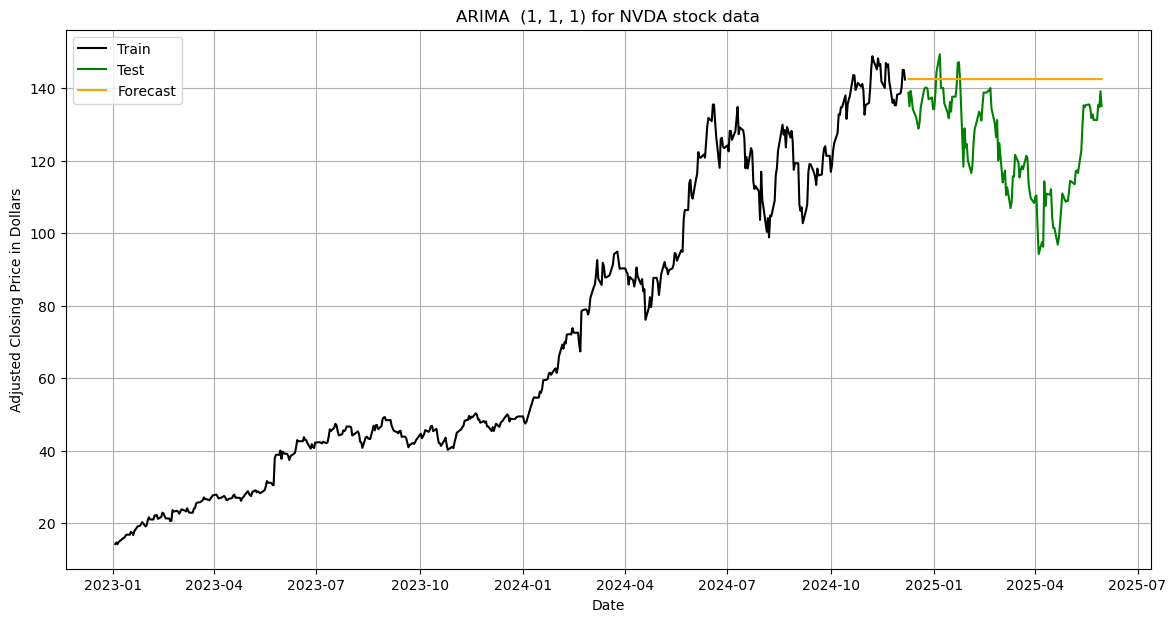

RMSE: 22.2433


In [ ]:
nvidia_new = pd.DataFrame(yf.download("NVDA", start="2023-01-01", end="2025-06-01", auto_adjust=False)[["Adj Close"]]).dropna()
nvidia_new = nvidia_new.asfreq(freq = "B", method = "ffill")

# Split data into train and test
train = nvidia_new.iloc[:-int(len(nvidia_new) * 0.2)]
test = nvidia_new.iloc[-int(len(nvidia_new) * 0.2):]

# Fit ARIMA model
model = ARIMA(train["Adj Close"], order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot the results
plt.figure(figsize=(14,7))
plt.grid(True)
plt.title("ARIMA  (1, 1, 1) for NVDA stock data")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price in Dollars")
plt.plot(train.index, train["Adj Close"], label="Train", color="black")
plt.plot(test.index, test["Adj Close"], label="Test", color="Green")
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.legend()
plt.show()

#Calculate RMSE
forecast = forecast[:len(test)]
test_close = test["Adj Close"][:len(forecast)]
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")

**Description:** We can see that the frequency warning is gone. I applied .asfreq() and set the frequency to business days. I also included ffill (forward fill) to fill in empty value based on the last available data. This ensures contnuity of the data. The forecast is still a flat line.

I will now implement prophet model.

# **8. Prophet Model**

Prophet is developed by Facebook. It is an open source library that is used for time series forecasting. It uses the following formula to generate forecasts. The formula is further explained in my seminar thesis.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + \epsilon_t\
\end{equation}

18:04:25 - cmdstanpy - INFO - Chain [1] start processing
18:04:26 - cmdstanpy - INFO - Chain [1] done processing


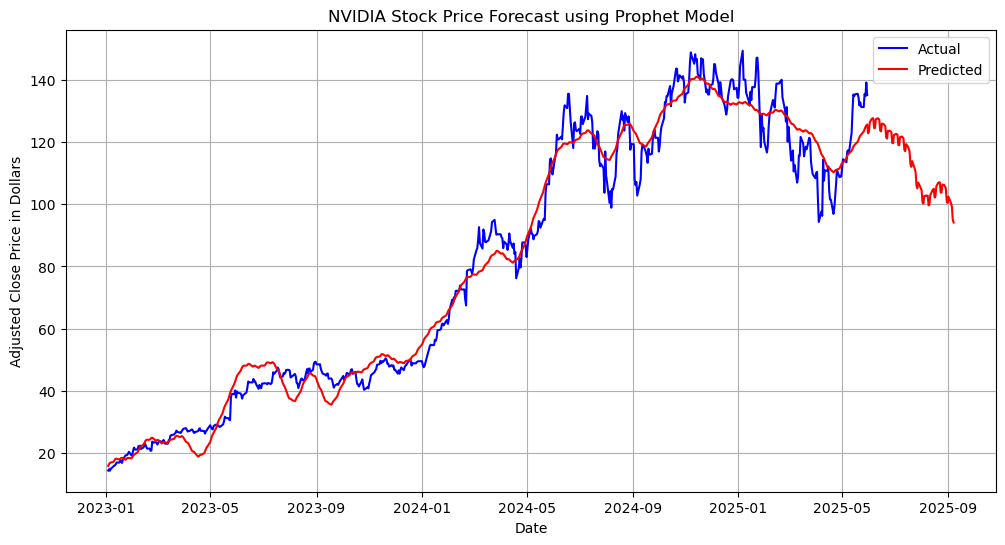

RMSE: 6.26


In [ ]:
# Rename columns for Prophet format
nvidia_prophet = nvidia_new.reset_index()
nvidia_prophet.columns = ["ds", "y"]

# Create and fit model
model = Prophet()
model.fit(nvidia_prophet)

# Generate future dates
future = model.make_future_dataframe(periods = 100)
forecast = model.predict(future)

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.grid(True)
plt.plot(nvidia_prophet['ds'], nvidia_prophet['y'], label='Actual', color='blue')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='red')
plt.title('NVIDIA Stock Price Forecast using Prophet Model')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price in Dollars')
plt.legend()
plt.show()

# Calculate RMSE
actual = nvidia_prophet['y']
predicted = forecast['yhat'][:len(actual)]
rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"RMSE: {rmse:.2f}")

**Description:** This gives a better prediction of my data. The RMSE value of 6.26 is also much lower than ARIMA (1, 1, 1) model. Lets look at why the Prophet model gives a better result.

Prophet model handles all the possible effects that might exist in the model. There might have been trends or minor seasonality that ARIMA model was not able to capture. Also, the prophet model includes the error term which accounts for any unusual changes. This might help the model understand historical data better and predict better. 

# **9. Monte Carlo Simulation for future price paths**

Now i will use monte carlo simulation to simulate different future price paths.

# (a) Calculating log returns

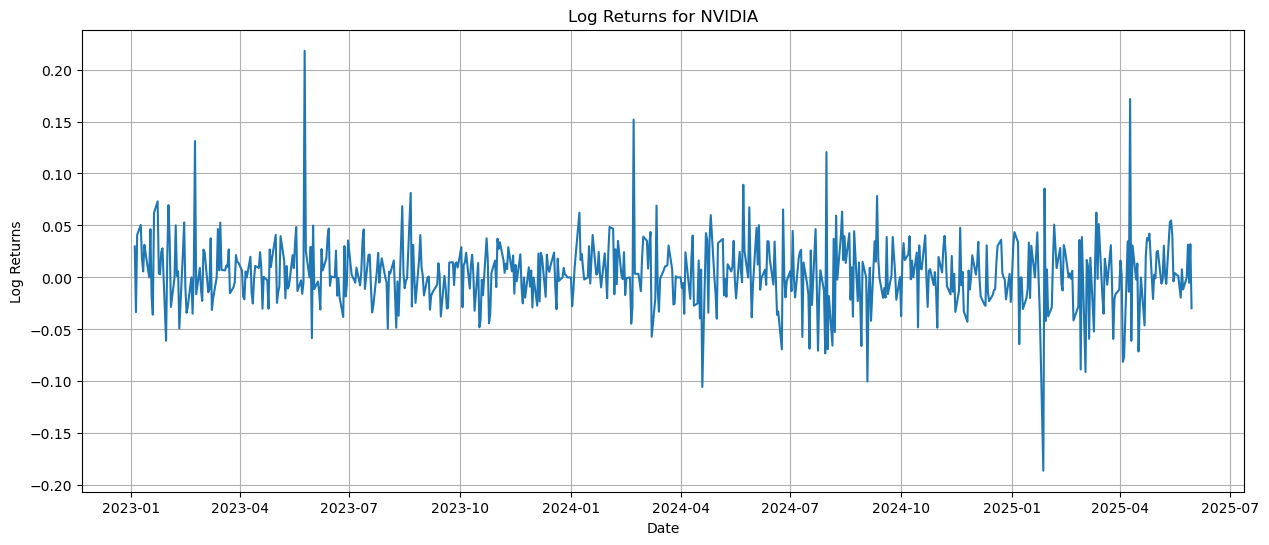

In [ ]:
# Finding log returns
nvidia_new["Log Returns"] = np.log(nvidia_new["Adj Close"]/nvidia_new["Adj Close"].shift(1))
nvidia_new.dropna(inplace=True)

# Plotting log returns
plt.figure(figsize=(15, 6))
plt.grid(True)
plt.ylabel("Log Returns")
plt.xlabel("Date")
plt.title("Log Returns for NVIDIA")
plt.plot(nvidia_new["Log Returns"])
plt.show()

# (b) Simulating Monte Carlo price paths

My model assumes that the future prices depend on the growth factor. This growth factor is calculated using historical returns and standard deviation of Nvidia stock prices.

\begin{equation}
P_t = P_0 \times \prod_{i=1}^{t} (1 + r_i)
\end{equation}

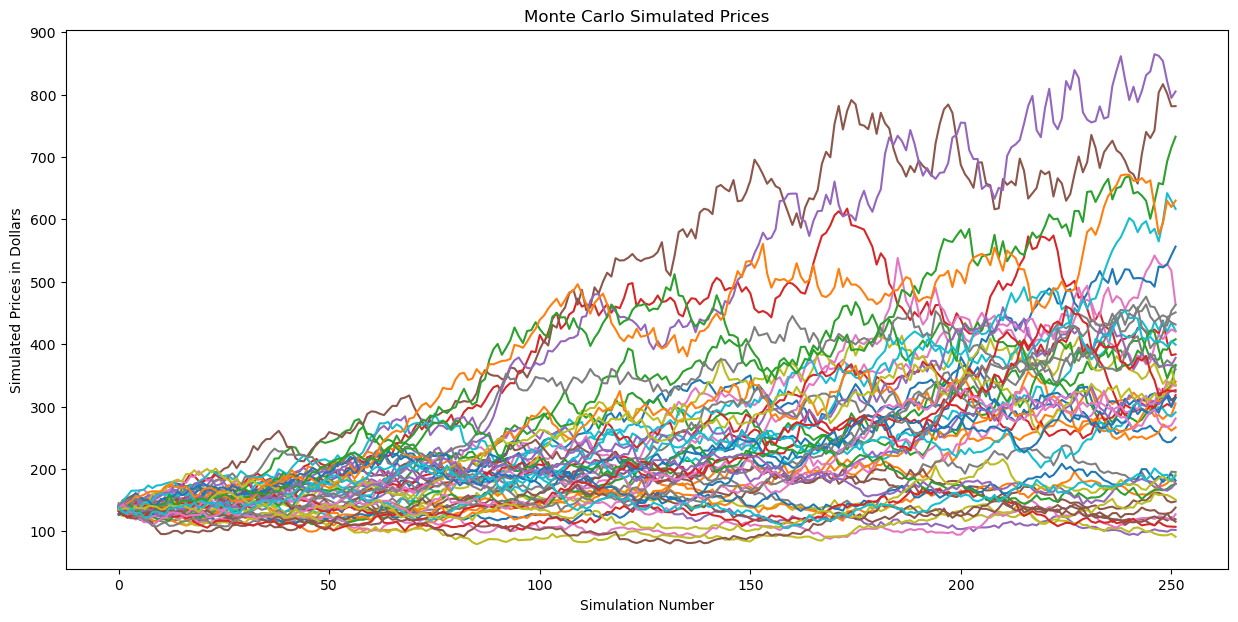

In [ ]:
# Calculating mean and standard deviation
mean = nvidia_new["Log Returns"].mean()
std = nvidia_new["Log Returns"].std()

# Getting the most recent price as initial price
initial_price = nvidia_new["Adj Close"].iloc[-1].item()

# Initiating plot figure
plt.figure(figsize=(15, 7))
plt.title("Monte Carlo Simulated Prices")
plt.xlabel("Simulation Number")
plt.ylabel("Simulated Prices in Dollars")

# For loop for generating simulations
for i in range(50):
    sim_returns = np.random.normal(mean,std,252)
    sim_prices = initial_price * (sim_returns + 1).cumprod()
    plt.plot(sim_prices)

**Description:** Let me mention in steps about how the above results are derived:
- initial_price gets the last Nvidia stock price from the data.
- sim_returns gets 252 random values of log returns based on the given mean and standard deviation that we calculated.
- (sim_returns + 1) converts the returns to multiplicative factor.
- cumprod() finds growth factor by calculating the cumulative product of these multiplicative factors.
- We multiply this growth factor by the initial_price to get the simulated price.
- for loop runs for 50 simulations and generates 50 different price paths.

# **10. Monte Carlo Simulation for European Option Valuation**


\begin{equation}
S_{\text{fwd}} = S_0 \cdot \exp\left( \left( r - \frac{1}{2} \sigma^2 \right) T + \sigma \sqrt{T} z \right)
\end{equation}

- S_fwd is the predicted future stock price.
- S_0 is the initial stock price which I will be using as the last known stock price.
- sigma is the volatility of underlying asset
- T is the time to expiration of the option
- z is the randomly generated number for Monte carlo simulation.

\begin{equation}
Call Price = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \text{Payoff}_i
\end{equation}

I will be using this formula to find call price. This basically finds the average of all possible future payoffs and discounts them to the presesnt value to give call price.

Flow of my program:

- I am going to use the formula above for predicting future stock prices using monte carlo simulation.
- Then I will be calculating payoffs of an european call option based on these future prices.
- Then I will discount the payoffs back to the present value using risk free rate.
- I will take the average of these payoffs to get the call option premium.
- I will also be plotting the payoffs.

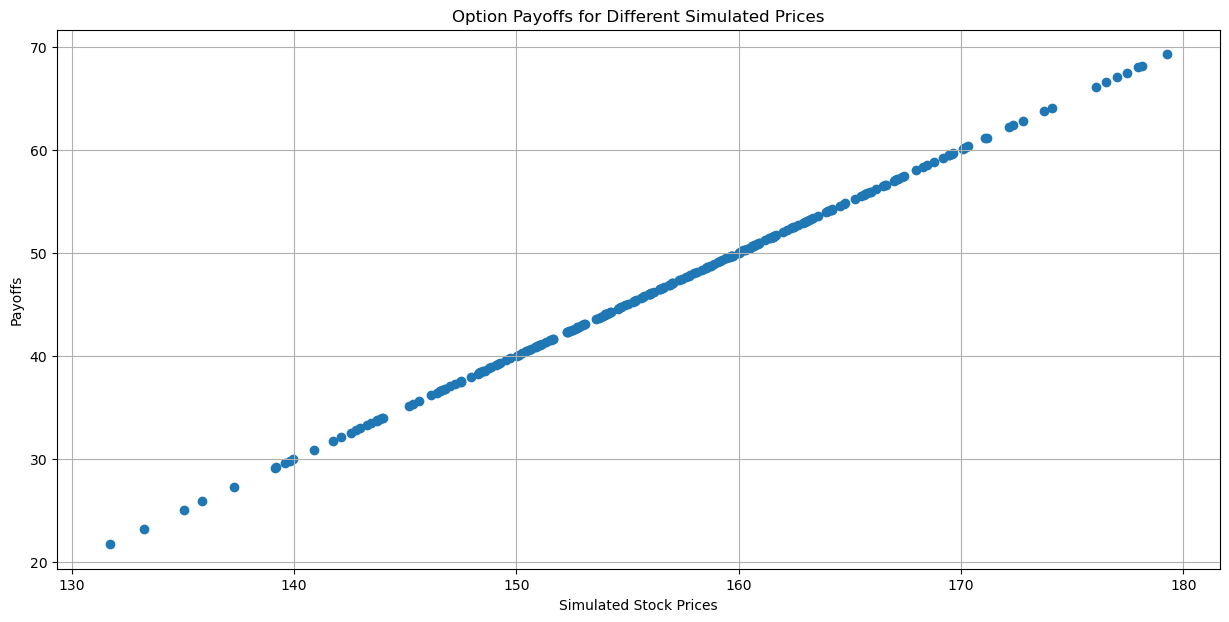

Call price: 40.332445605075996


In [ ]:
# Calculating volatility
stock_volatility = nvidia_new["Log Returns"].std()

# Defining Monte Carlo function
def european_option_valuation(S0, K, r, v, T, numSims):
    
    total_payoff = 0
    payoffs = []
    S_fwds = []
    
    for _ in range(numSims):
        z = np.random.standard_normal()
        S_fwd = S0 * np.exp((r-0.5*v**2)*T + v*np.sqrt(T)*z) 
        S_fwds.append(S_fwd) 
        payoff = np.maximum(S_fwd - K, 0)
        payoffs.append(payoff)
        total_payoff += payoff

    # Plotting the payoffs
    plt.figure(figsize=(15, 7))
    plt.grid(True)
    plt.scatter(S_fwds, payoffs, marker='o')
    plt.title("Option Payoffs for Different Simulated Prices")
    plt.xlabel("Simulated Stock Prices")
    plt.ylabel("Payoffs")
    plt.show()
    
    return np.exp(-r*T) * (total_payoff/numSims)

# Calling the function
call_price = european_option_valuation(
    nvidia_new["Adj Close"].iloc[-1].item(),
    110,
    0.05,
    stock_volatility,
    3,
    250
)

# Prinitng call price
print("Call price:", call_price)

**Description:** We can see that our model follows a call option trajectory. We can change the call option information like risk free rate, time to expiry and strike price to simulate different results.

# **11. Real life Option Valuation**

I found a real life call option for Nvidia with the following data:
- Strike Price (k) = 110
- Implied Volatility (v) = 46.21%
- Expiration date (time to maturity) (T) = 2027-06-17

I am going to plug these values in my model above to evaluate this option. I am going to use risk free rate = 3% and time to expiration = 2 years.

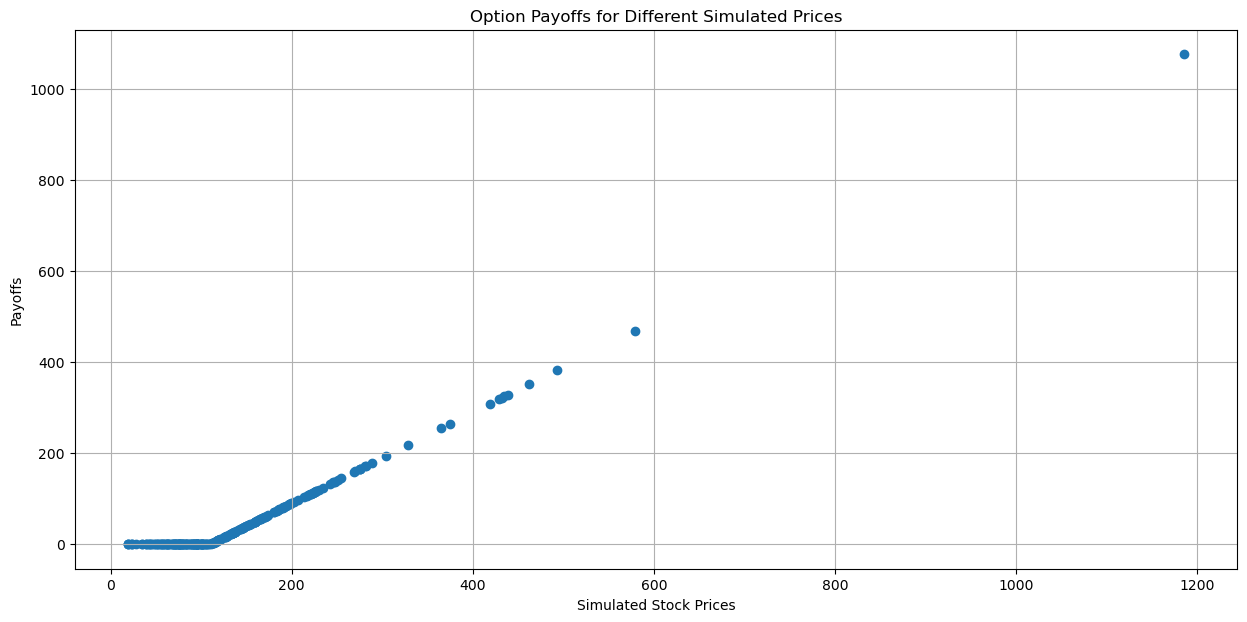

Call price: 45.83213463737615


In [ ]:
# Calling the function
call_price = european_option_valuation(
    nvidia_new["Adj Close"].iloc[-1].item(),
    110,
    0.03,
    0.4621,
    2,
    250
)

# Prinitng call price
print("Call price:", call_price)